# Flight Line Optimization

The `flight_optimizer` module solves the problem of ordering flight lines
to minimize total transit time while respecting aircraft constraints:
endurance limits, daily flight-time budgets, and multi-day scheduling.

It works in two steps:

1. **`build_graph`** — Constructs a directed graph connecting all flight line
   endpoints and airports, with edges weighted by transit time.
2. **`greedy_optimize`** — Traverses the graph using a nearest-neighbor
   heuristic, inserting refuel stops and day breaks as needed.

We cover:

1. Building the transit-time graph
2. Basic greedy optimization
3. Endurance and refueling constraints
4. Multi-day scheduling
5. Inspecting the optimized route
6. Feeding the result into `compute_flight_plan`

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import logging
logging.basicConfig(level=logging.INFO, format="%(message)s")

import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Polygon

from hyplan import (
    FlightLine, AVIRIS3,
    DynamicAviation_B200,
    Airport, initialize_data,
    box_around_polygon,
    build_graph, greedy_optimize,
    compute_flight_plan, plot_flight_plan, plot_altitude_trajectory,
    map_flight_lines,
    ureg,
)

## Setup: Flight Lines and Airports

We generate a set of flight lines over a study area and select
airports for departure, return, and potential refueling.

In [2]:
# Initialize airport database
initialize_data(countries=["US"])

# Define sensor and aircraft
sensor = AVIRIS3()
aircraft = DynamicAviation_B200()
altitude = ureg.Quantity(20000, "feet")

# Study area polygon (larger region around Channel Islands)
study_area = Polygon([
    (-120.50, 34.20), (-120.40, 34.00), (-120.10, 33.85),
    (-119.70, 33.80), (-119.40, 33.90), (-119.30, 34.05),
    (-119.40, 34.20), (-119.70, 34.30), (-120.10, 34.35),
    (-120.40, 34.25), (-120.50, 34.20),
])

# Generate flight lines
flight_lines = box_around_polygon(
    instrument=sensor,
    altitude_msl=altitude,
    polygon=study_area,
    box_name="ISL",
    overlap=20.0,
    clip_to_polygon=False,
)

# Select airports
departure = Airport("KSBA")  # Santa Barbara
refuel = Airport("KOXR")    # Oxnard
airports = [departure, refuel]

print(f"{len(flight_lines)} flight lines generated")
print(f"Departure: {departure.name} ({departure.icao_code})")
print(f"Refuel option: {refuel.name} ({refuel.icao_code})")

The file at /Users/rpavlick/.cache/hyplan/airports.csv already exists. Skipping download.
The file at /Users/rpavlick/.cache/hyplan/runways.csv already exists. Skipping download.
Using minimum rotated rectangle for polygon bounding box.
Bounding box derived: Center=(34.074889, -119.908908), Azimuth=98.23°, Length=111937.46 m, Width=54882.40 m.
Calculated swath spacing: 3511.51 meter meters.
Number of lines: 16.


16 flight lines generated
Departure: Santa Barbara Municipal Airport (KSBA)
Refuel option: Oxnard Airport (KOXR)


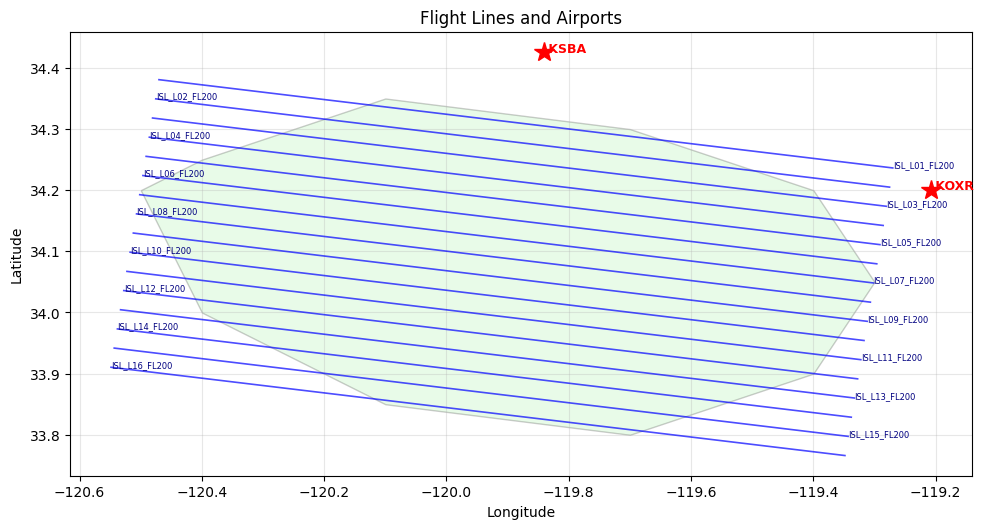

In [3]:
# Visualize the setup
fig, ax = plt.subplots(figsize=(10, 6))
gpd.GeoSeries([study_area]).plot(ax=ax, alpha=0.2, edgecolor="black", color="lightgreen")

for fl in flight_lines:
    x, y = fl.geometry.xy
    ax.plot(x, y, "b-", linewidth=1.2, alpha=0.7)
    ax.annotate(fl.site_name, xy=(x[0], y[0]), fontsize=6, color="navy")

for apt in airports:
    ax.plot(apt.longitude, apt.latitude, "r*", markersize=15)
    ax.annotate(f" {apt.icao_code}", xy=(apt.longitude, apt.latitude),
                fontsize=9, color="red", fontweight="bold")

ax.set_title("Flight Lines and Airports")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 1. Building the Transit-Time Graph

`build_graph` creates a directed graph (NetworkX DiGraph) where:

- **Nodes** represent airport locations and flight line endpoints (start/end)
- **Edges** represent transit connections weighted by time in hours
- Edge types: `departure`, `flight_line`, `transit`, `return`

This graph encodes all possible transitions between flight lines and airports.

In [4]:
G = build_graph(aircraft, flight_lines, airports)

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Count node types
node_types = {}
for node, data in G.nodes(data=True):
    ntype = data.get("nodetype", "unknown")
    node_types[ntype] = node_types.get(ntype, 0) + 1
print(f"Node types: {node_types}")

# Count edge types
edge_types = {}
for u, v, data in G.edges(data=True):
    etype = data.get("edgetype", "unknown")
    edge_types[etype] = edge_types.get(etype, 0) + 1
print(f"Edge types: {edge_types}")

Graph: 34 nodes, 1122 edges
Node types: {'airport': 2, 'flight_line_endpoint': 32}
Edge types: {'departure': 64, 'transit': 962, 'flight_line': 32, 'return': 64}


In [5]:
# Example: transit time from departure airport to first flight line endpoints
print(f"Transit times from {departure.icao_code}:")
for neighbor in list(G.neighbors(departure.icao_code))[:6]:
    edge = G[departure.icao_code][neighbor]
    print(f"  -> {neighbor}: {edge['weight']:.2f} hr ({edge['edgetype']})")

Transit times from KSBA:
  -> ISL_L01_FL200_start: 0.17 hr (departure)
  -> ISL_L01_FL200_end: 1.53 hr (departure)
  -> ISL_L02_FL200_start: 0.17 hr (departure)
  -> ISL_L02_FL200_end: 1.26 hr (departure)
  -> ISL_L03_FL200_start: 0.17 hr (departure)
  -> ISL_L03_FL200_end: 1.16 hr (departure)


## 2. Basic Greedy Optimization

`greedy_optimize` uses a nearest-neighbor heuristic to order flight
lines. Starting from the takeoff airport, it repeatedly selects the
closest reachable unvisited flight line.

In [6]:
result = greedy_optimize(
    aircraft=aircraft,
    flight_lines=flight_lines,
    airports=airports,
    takeoff_airport=departure,
    return_airport=departure,
    max_endurance=8.0,           # generous endurance
    max_daily_flight_time=12.0,  # generous daily limit
    max_days=1,
)

print(f"Lines covered: {result['lines_covered']}/{len(flight_lines)}")
print(f"Total time:    {result['total_time']:.2f} hours")
print(f"Days used:     {result['days_used']}")
print(f"Refuel stops:  {result['refuel_stops']}")
print(f"\nRoute: {' -> '.join(result['route'])}")

Building flight graph for 16 lines and 2 airports...
Starting greedy optimization from KSBA
--- Day 1 ---
  Flew ISL_L07_FL200 (1/16), day time: 0.44h, since refuel: 0.44h
  Flew ISL_L08_FL200 (2/16), day time: 0.74h, since refuel: 0.74h
  Flew ISL_L09_FL200 (3/16), day time: 1.04h, since refuel: 1.04h
  Flew ISL_L10_FL200 (4/16), day time: 1.34h, since refuel: 1.34h
  Flew ISL_L11_FL200 (5/16), day time: 1.64h, since refuel: 1.64h
  Flew ISL_L12_FL200 (6/16), day time: 1.94h, since refuel: 1.94h
  Flew ISL_L13_FL200 (7/16), day time: 2.25h, since refuel: 2.25h
  Flew ISL_L14_FL200 (8/16), day time: 2.55h, since refuel: 2.55h
  Flew ISL_L15_FL200 (9/16), day time: 2.85h, since refuel: 2.85h
  Flew ISL_L16_FL200 (10/16), day time: 3.15h, since refuel: 3.15h
  Flew ISL_L06_FL200 (11/16), day time: 3.51h, since refuel: 3.51h
  Flew ISL_L05_FL200 (12/16), day time: 3.82h, since refuel: 3.82h
  Flew ISL_L04_FL200 (13/16), day time: 4.12h, since refuel: 4.12h
  Flew ISL_L03_FL200 (14/16), da

Lines covered: 16/16
Total time:    5.24 hours
Days used:     1
Refuel stops:  []

Route: KSBA -> ISL_L07_FL200_end -> ISL_L07_FL200_start -> ISL_L08_FL200_end -> ISL_L08_FL200_start -> ISL_L09_FL200_end -> ISL_L09_FL200_start -> ISL_L10_FL200_end -> ISL_L10_FL200_start -> ISL_L11_FL200_end -> ISL_L11_FL200_start -> ISL_L12_FL200_end -> ISL_L12_FL200_start -> ISL_L13_FL200_end -> ISL_L13_FL200_start -> ISL_L14_FL200_end -> ISL_L14_FL200_start -> ISL_L15_FL200_end -> ISL_L15_FL200_start -> ISL_L16_FL200_end -> ISL_L16_FL200_start -> ISL_L06_FL200_start -> ISL_L06_FL200_end -> ISL_L05_FL200_start -> ISL_L05_FL200_end -> ISL_L04_FL200_start -> ISL_L04_FL200_end -> ISL_L03_FL200_start -> ISL_L03_FL200_end -> ISL_L02_FL200_start -> ISL_L02_FL200_end -> ISL_L01_FL200_start -> ISL_L01_FL200_end -> KSBA


In [7]:
# Optimized flight sequence
print("Optimized flight line order:")
for i, fl in enumerate(result["flight_sequence"], 1):
    print(f"  {i}. {fl.site_name} (az={fl.az12.magnitude:.1f}°)")

Optimized flight line order:
  1. ISL_L07_FL200 (az=97.9°)
  2. ISL_L08_FL200 (az=278.6°)
  3. ISL_L09_FL200 (az=97.9°)
  4. ISL_L10_FL200 (az=278.6°)
  5. ISL_L11_FL200 (az=97.9°)
  6. ISL_L12_FL200 (az=278.5°)
  7. ISL_L13_FL200 (az=97.9°)
  8. ISL_L14_FL200 (az=278.5°)
  9. ISL_L15_FL200 (az=97.9°)
  10. ISL_L16_FL200 (az=278.5°)
  11. ISL_L06_FL200 (az=97.9°)
  12. ISL_L05_FL200 (az=278.6°)
  13. ISL_L04_FL200 (az=97.9°)
  14. ISL_L03_FL200 (az=278.6°)
  15. ISL_L02_FL200 (az=97.9°)
  16. ISL_L01_FL200 (az=278.6°)


## 3. Endurance and Refueling

When `max_endurance` is set to a realistic value, the optimizer will
automatically insert refueling stops at the nearest airport when the
aircraft can no longer reach another flight line and return safely.

In [8]:
result_constrained = greedy_optimize(
    aircraft=aircraft,
    flight_lines=flight_lines,
    airports=airports,
    takeoff_airport=departure,
    return_airport=departure,
    max_endurance=3.0,             # tighter endurance → forces refueling
    refuel_time=0.5,               # 30 min refuel
    max_daily_flight_time=12.0,
    max_days=1,
)

print(f"Lines covered: {result_constrained['lines_covered']}/{len(flight_lines)}")
print(f"Total time:    {result_constrained['total_time']:.2f} hours")
print(f"Refuel stops:  {result_constrained['refuel_stops']}")
print(f"Skipped lines: {result_constrained['lines_skipped']}")

Building flight graph for 16 lines and 2 airports...
Starting greedy optimization from KSBA
--- Day 1 ---
  Flew ISL_L07_FL200 (1/16), day time: 0.44h, since refuel: 0.44h
  Flew ISL_L08_FL200 (2/16), day time: 0.74h, since refuel: 0.74h
  Flew ISL_L09_FL200 (3/16), day time: 1.04h, since refuel: 1.04h
  Flew ISL_L10_FL200 (4/16), day time: 1.34h, since refuel: 1.34h
  Flew ISL_L11_FL200 (5/16), day time: 1.64h, since refuel: 1.64h
  Flew ISL_L12_FL200 (6/16), day time: 1.94h, since refuel: 1.94h
  Flew ISL_L13_FL200 (7/16), day time: 2.25h, since refuel: 2.25h
Refueling at KOXR (time since last refuel: 2.25h)
  Flew ISL_L16_FL200 (8/16), day time: 3.41h, since refuel: 0.44h
  Flew ISL_L15_FL200 (9/16), day time: 3.71h, since refuel: 0.74h
  Flew ISL_L14_FL200 (10/16), day time: 4.01h, since refuel: 1.04h
  Flew ISL_L06_FL200 (11/16), day time: 4.36h, since refuel: 1.39h
  Flew ISL_L05_FL200 (12/16), day time: 4.66h, since refuel: 1.69h
  Flew ISL_L04_FL200 (13/16), day time: 4.96h, si

Lines covered: 16/16
Total time:    6.95 hours
Refuel stops:  ['KOXR', 'KSBA']
Skipped lines: []


## 4. Multi-Day Scheduling

For campaigns with many flight lines, `max_days` > 1 allows the optimizer
to spread lines across multiple days. Each day starts fresh from the
takeoff airport with reset endurance and daily time counters.

In [9]:
result_multiday = greedy_optimize(
    aircraft=aircraft,
    flight_lines=flight_lines,
    airports=airports,
    takeoff_airport=departure,
    return_airport=departure,
    max_endurance=3.0,
    max_daily_flight_time=3.0,     # short daily budget → forces multiple days
    max_days=5,
)

print(f"Lines covered: {result_multiday['lines_covered']}/{len(flight_lines)}")
print(f"Days used:     {result_multiday['days_used']}")
print(f"Total time:    {result_multiday['total_time']:.2f} hours")
print(f"\nDaily breakdown:")
for i, dt in enumerate(result_multiday["daily_times"], 1):
    print(f"  Day {i}: {dt:.2f} hours")
print(f"\nRefuel stops: {result_multiday['refuel_stops']}")
print(f"Skipped lines: {result_multiday['lines_skipped']}")

Building flight graph for 16 lines and 2 airports...
Starting greedy optimization from KSBA
--- Day 1 ---
  Flew ISL_L07_FL200 (1/16), day time: 0.44h, since refuel: 0.44h
  Flew ISL_L08_FL200 (2/16), day time: 0.74h, since refuel: 0.74h
  Flew ISL_L09_FL200 (3/16), day time: 1.04h, since refuel: 1.04h
  Flew ISL_L10_FL200 (4/16), day time: 1.34h, since refuel: 1.34h
  Flew ISL_L11_FL200 (5/16), day time: 1.64h, since refuel: 1.64h
  Flew ISL_L12_FL200 (6/16), day time: 1.94h, since refuel: 1.94h
  Flew ISL_L13_FL200 (7/16), day time: 2.25h, since refuel: 2.25h
Refueling at KOXR (time since last refuel: 2.25h)
Day 1: Not enough daily time to refuel. Ending day.
Day 1 complete: 3.16h flown
--- Day 2 ---
  Flew ISL_L01_FL200 (8/16), day time: 0.44h, since refuel: 0.44h
  Flew ISL_L02_FL200 (9/16), day time: 0.74h, since refuel: 0.74h
  Flew ISL_L03_FL200 (10/16), day time: 1.04h, since refuel: 1.04h
  Flew ISL_L04_FL200 (11/16), day time: 1.34h, since refuel: 1.34h
  Flew ISL_L05_FL200 (

Lines covered: 16/16
Days used:     3
Total time:    6.75 hours

Daily breakdown:
  Day 1: 3.16 hours
  Day 2: 2.54 hours
  Day 3: 1.05 hours

Refuel stops: ['KOXR']
Skipped lines: []


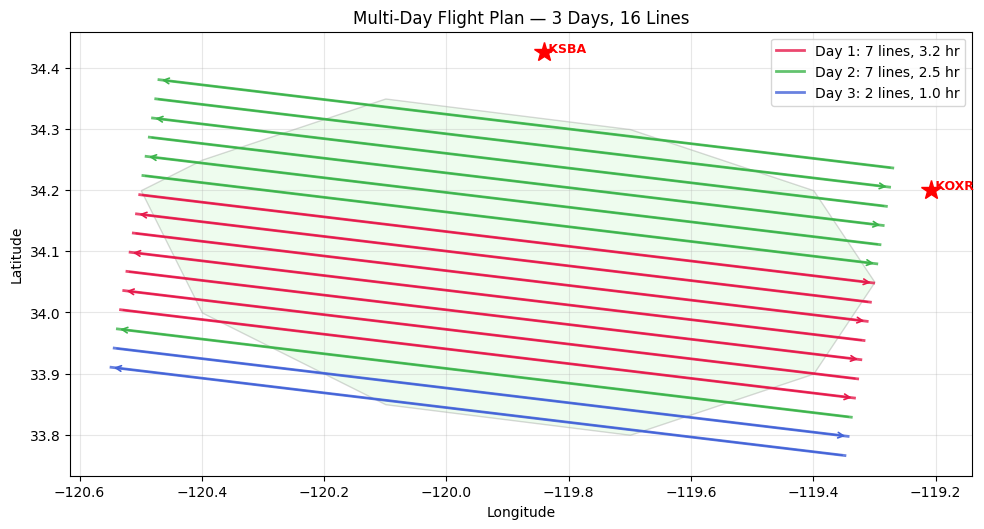

In [10]:
# Visualize multi-day schedule — color-code lines by day
fig, ax = plt.subplots(figsize=(10, 7))
gpd.GeoSeries([study_area]).plot(ax=ax, alpha=0.15, edgecolor="black", color="lightgreen")

# Split flight sequence into daily groups using the route
# Day breaks appear as consecutive return-airport nodes
route = result_multiday["route"]
return_icao = departure.icao_code
seq = result_multiday["flight_sequence"]
line_names = [fl.site_name for fl in seq]

groups = []
current_group = []
seq_idx = 0
for i, node in enumerate(route):
    # Check if this node is a flight line start/end
    base_name = node.rsplit("_start", 1)[0].rsplit("_end", 1)[0]
    if base_name in line_names and seq_idx < len(seq) and base_name == line_names[seq_idx]:
        if not current_group or current_group[-1].site_name != base_name:
            current_group.append(seq[seq_idx])
            seq_idx += 1
    # Day break: return airport followed by same airport (or end of route)
    elif node == return_icao and current_group:
        groups.append(current_group)
        current_group = []
if current_group:
    groups.append(current_group)

day_colors = ["#e6194b", "#3cb44b", "#4363d8", "#f58231", "#911eb4"]
for day_idx, group in enumerate(groups):
    color = day_colors[day_idx % len(day_colors)]
    dt = result_multiday["daily_times"][day_idx]
    for i, fl in enumerate(group):
        x, y = fl.geometry.xy
        label = f"Day {day_idx + 1}: {len(group)} lines, {dt:.1f} hr" if i == 0 else None
        ax.plot(x, y, color=color, linewidth=2, alpha=0.8, label=label)
        ax.annotate("", xy=(x[-1], y[-1]), xytext=(x[0], y[0]),
                    arrowprops=dict(arrowstyle="->", color=color, lw=1.2))

for apt in airports:
    ax.plot(apt.longitude, apt.latitude, "r*", markersize=15, zorder=5)
    ax.annotate(f" {apt.icao_code}", xy=(apt.longitude, apt.latitude),
                fontsize=9, color="red", fontweight="bold")

ax.set_title(f"Multi-Day Flight Plan — {result_multiday['days_used']} Days, "
             f"{result_multiday['lines_covered']} Lines")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Feeding Results into `compute_flight_plan`

The optimized `flight_sequence` plugs directly into `compute_flight_plan`
to produce a detailed segment-by-segment plan with geometry, timing,
and altitude information.

In [11]:
plan = compute_flight_plan(
    aircraft=aircraft,
    flight_sequence=result["flight_sequence"],
    takeoff_airport=departure,
    return_airport=departure,
)

total_time = plan["time_to_segment"].sum()
data_time = plan[plan["segment_type"] == "flight_line"]["time_to_segment"].sum()

print(f"Flight plan: {len(plan)} segments")
print(f"Total time: {total_time:.1f} min ({total_time/60:.1f} hr)")
print(f"Data collection: {data_time:.1f} min ({data_time/total_time*100:.1f}%)")

Flight plan: 33 segments
Total time: 347.8 min (5.8 hr)
Data collection: 287.1 min (82.5%)


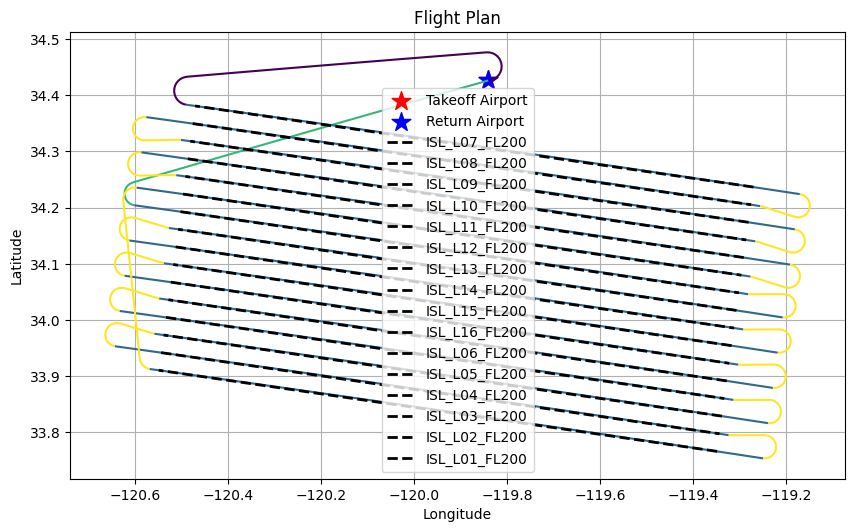

In [12]:
plot_flight_plan(plan, departure, departure, result["flight_sequence"])

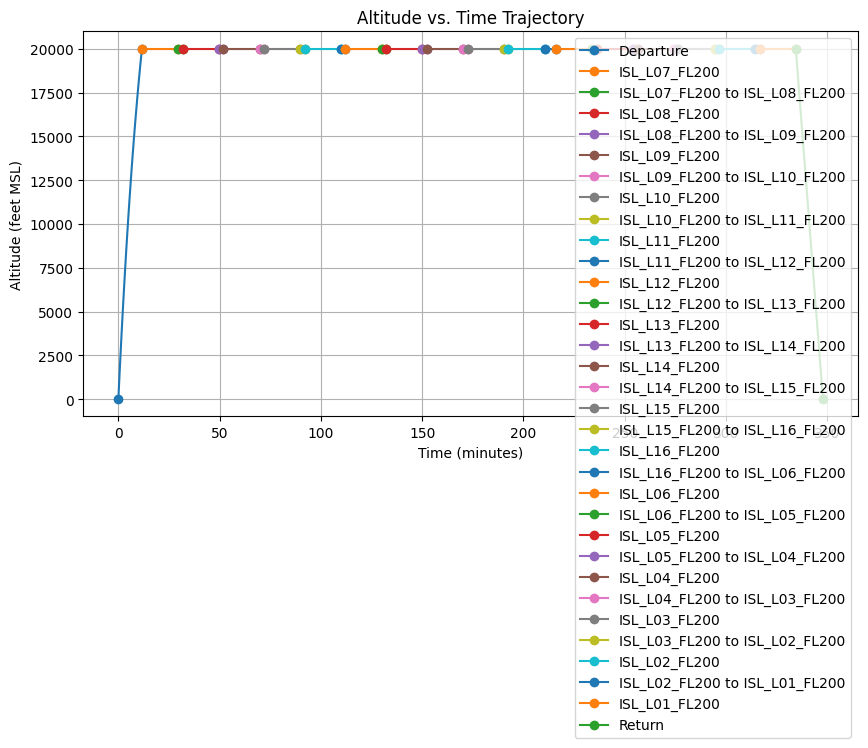

In [13]:
plot_altitude_trajectory(plan, aircraft=aircraft, show_terrain=False)

## 6. Interactive Map

Visualize the optimized flight lines on an interactive Folium map.

In [14]:
centroid = study_area.centroid
m = map_flight_lines(
    result["flight_sequence"],
    center=(centroid.y, centroid.x),
    zoom_start=10,
)
m

## Summary

| Function | Purpose |
|----------|---------|
| `build_graph(aircraft, flight_lines, airports)` | Create the transit-time graph |
| `greedy_optimize(aircraft, flight_lines, airports, ...)` | Greedy nearest-neighbor line ordering |

**Key parameters for `greedy_optimize`:**
- `max_endurance` — Hours before refueling is required (default: aircraft endurance)
- `refuel_time` — Ground time for refueling in hours (default: 0.5)
- `max_daily_flight_time` — Maximum flying hours per day
- `takeoff_landing_overhead` — Time for takeoff/landing procedures (default: 0.25 hr)
- `max_days` — Maximum number of flight days (default: 1)

**Return dict keys:**
- `flight_sequence` — Ordered list of FlightLine objects (ready for `compute_flight_plan`)
- `route` — Node names traversed through the graph
- `total_time`, `daily_times` — Timing in hours
- `lines_covered`, `lines_skipped` — Coverage statistics
- `refuel_stops` — Airport ICAO codes where refueling occurred
- `graph` — The underlying NetworkX DiGraph